In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


# Retail Sales Analysis and Business Insights

## Project Overview
This project analyzes a retail sales dataset from a superstore business to understand sales performance across time, regions, customer segments, and product categories.

The goal is to identify key business patterns, uncover sales concentration risks, and generate actionable recommendations that can support decision-making in sales, operations, and market expansion.

## Project Objectives
- Analyze overall sales trends over time
- Compare sales performance across regions
- Identify top-performing product categories and sub-categories
- Understand differences across customer segments
- Evaluate shipping time as an operational factor
- Generate business insights and recommendations 
This notebook combines exploratory data analysis, feature engineering, and time series forecasting in a business-oriented workflow.

## Business Problem

For a retail business, understanding where sales come from is essential for making better decisions in marketing, product strategy, and operations.

This analysis focuses on the following questions:

1. How do sales change over time?
2. Which regions contribute the most to revenue?
3. Which product categories and sub-categories are the most important?
4. Which customer segments drive the most sales?
5. Is there any sign of inefficiency in shipping time?

By answering these questions, the project aims to turn raw transaction data into practical business insights.

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Overview

In this section, we examine the basic structure of the dataset, including the number of rows, columns, data types, and missing values.

In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Initial Observations

The dataset contains transaction-level retail records with information about orders, customers, locations, shipping details, product categories, and sales values.

The target of this project is not prediction modeling, but business-oriented exploratory analysis and insight generation.

## Data Cleaning

Before analysis, we need to check for missing values, duplicated records, and convert date columns into proper datetime format.

In [7]:
df.isnull().sum().sort_values(ascending = False)

Postal Code      11
Row ID            0
Order ID          0
Order Date        0
Ship Mode         0
Ship Date         0
Customer Name     0
Segment           0
Country           0
Customer ID       0
City              0
State             0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Missing Values Handling

The `Postal Code` column contains a small number of missing values (11 records out of ~9800).  

Since this column is not used in the analysis and the missing proportion is negligible, no imputation or removal is performed.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst = True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst = True)
df.info()
df["Order Date"].head()
df["Ship Date"].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

0   2017-11-11
1   2017-11-11
2   2017-06-16
3   2016-10-18
4   2016-10-18
Name: Ship Date, dtype: datetime64[ns]

### Date Format Handling

The `Order Date` and `Ship Date` columns were stored in day-first format (DD/MM/YYYY).  

To ensure correct parsing, the `dayfirst=True` parameter was used when converting these columns to datetime format.

## Feature Engineering

To support time-based and operational analysis, following new columns are created from `Order Date` and `Ship Date`: `order_year`,`order_month`,`order_day`,`order_dayofweek`,`processing_days`.



In [10]:
df["order_year"] = df["Order Date"].dt.year
df["order_month"] = df["Order Date"].dt.month
df["order_day"] = df["Order Date"].dt.day
df["order_dayofweek"] = df["Order Date"].dt.day_name()
df["processing_days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,order_year,order_month,order_day,order_dayofweek,processing_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,8,Wednesday,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8,Wednesday,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,12,Monday,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11,Tuesday,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,11,Tuesday,7


## Sales Trend Analysis

Understanding sales over time helps identify growth patterns, fluctuations, and possible seasonality.


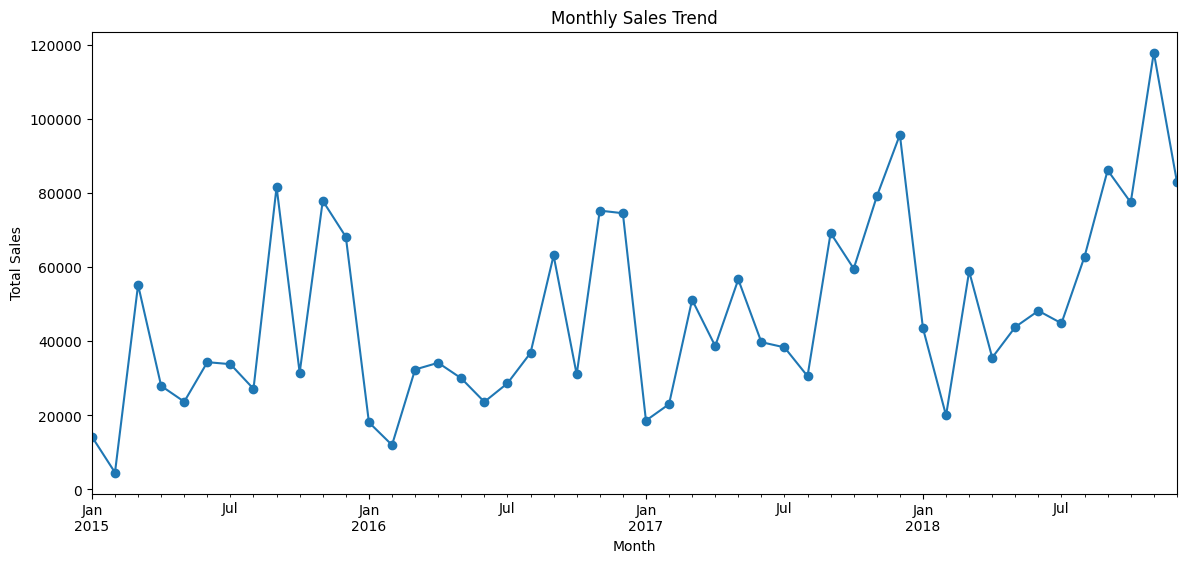

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


monthly_sales = df.resample("ME",on="Order Date")["Sales"].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


### Insight

Monthly sales show clear fluctuations with both trend and seasonal patterns.

Overall, sales have been increasing year over year, indicating steady business growth.

A strong seasonal pattern is observed: sales consistently peak in November and December, while January and February tend to have the lowest performance. This likely reflects holiday-driven demand at the end of the year followed by a post-holiday slowdown.

Additionally, September shows consistently strong sales, which may be associated with back-to-school demand, followed by the lower performance in October reflecting the post-back-to-schoole slowdown.

Sales begin to recover from March onwards, suggesting a recurring demand cycle across years.

No significant anomalies or unexpected spikes are observed, indicating relatively stable business behavior.

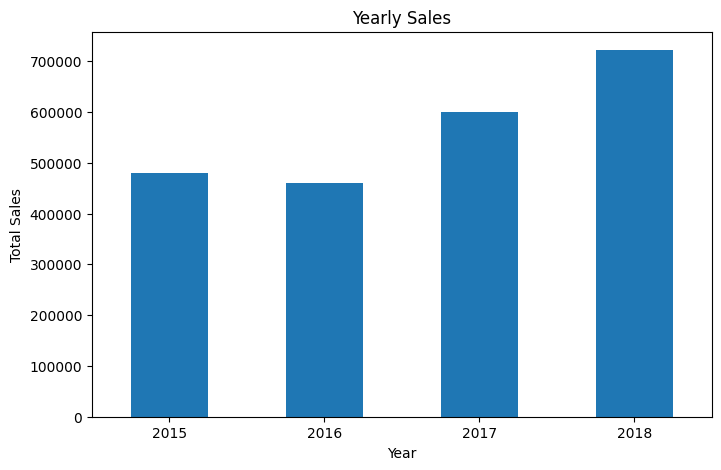

In [12]:
yearly_sales = df.groupby("order_year")["Sales"].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind="bar")
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()



### Insight

Yearly sales show a clear upward trend from 2015 to 2018, with total revenue increasing by approximately 40% over the period.

Despite a slight dip in 2016, the overall growth trajectory remains strong, indicating consistent business expansion.


## Regional Analysis

Identifying the strongest and weakest markets in order to support geographic expansion and resource allocation decisions.


Text(0.5, 0, 'Total Sales')

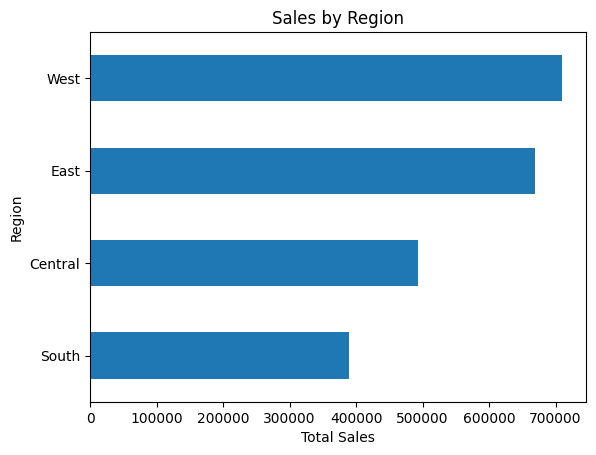

In [13]:
regional_sales = df.groupby("Region")["Sales"].sum().sort_values()

regional_sales.plot(kind="barh", title="Sales by Region")
plt.xlabel("Total Sales")

### Insight

Sales performance differs across regions, indicating that the business is more successful in the West markets and less successful in the South market.


## Geographic Concentration Analysis

This section evaluates whether sales are concentrated in a small number of states and cities, which can indicate reliance on key geographic markets.

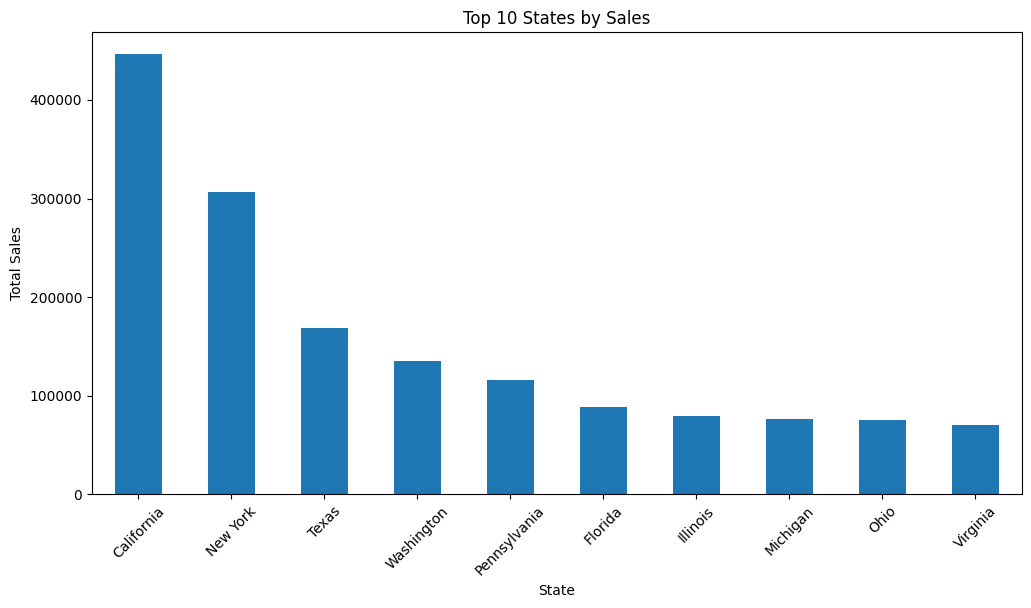

In [14]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_states.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


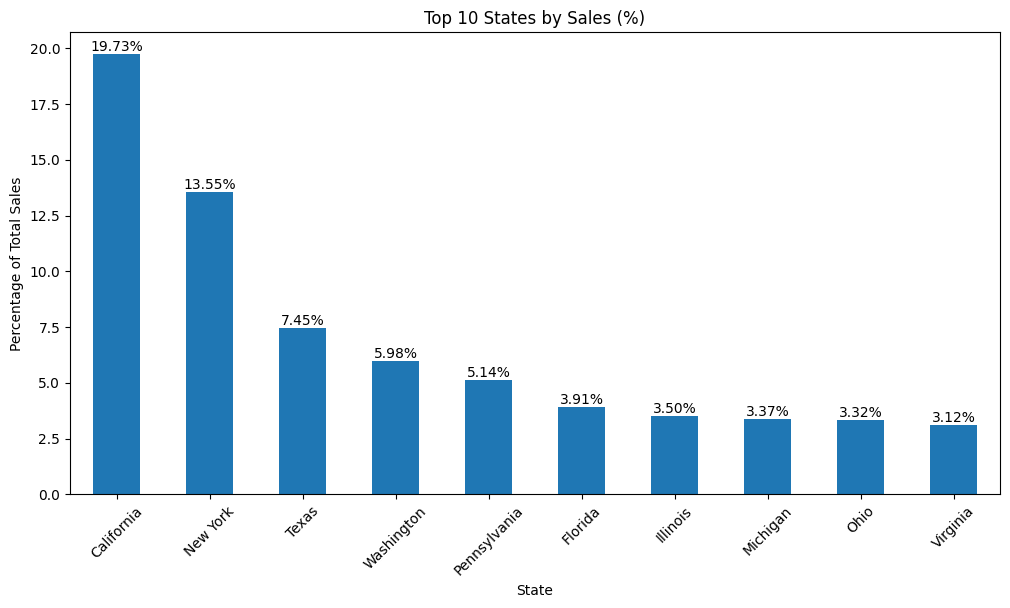

In [28]:
total_sales = df["Sales"].sum()

top_states_pct = (top_states / total_sales) * 100

plt.figure(figsize=(12,6))
ax = top_states_pct.plot(kind = "bar")
plt.title("Top 10 States by Sales (%)")
plt.xlabel("State")
plt.ylabel("Percentage of Total Sales")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")


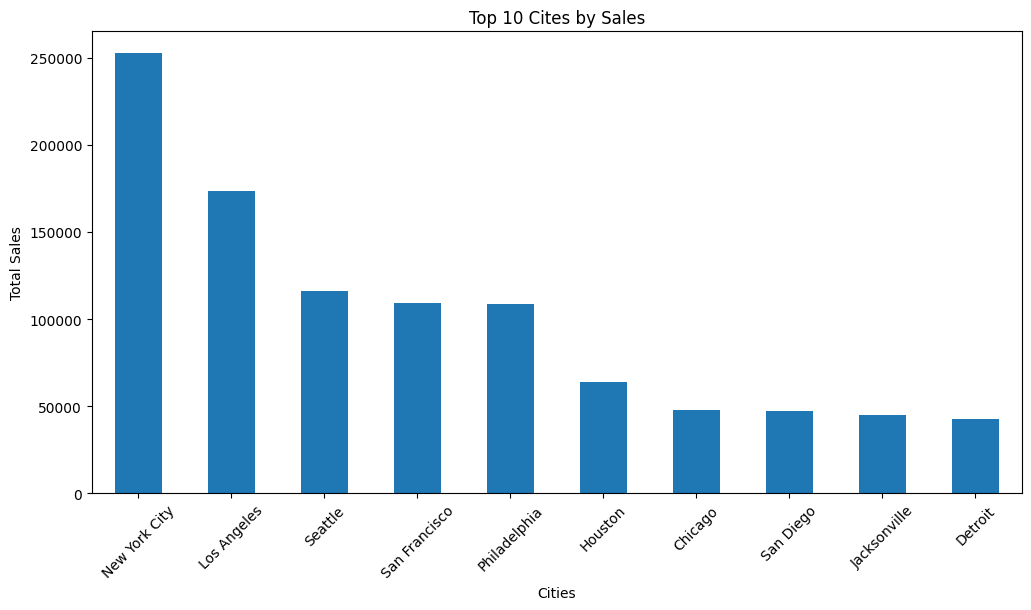

In [17]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
top_cities.plot(kind="bar")
plt.title("Top 10 Cites by Sales")
plt.xlabel("Cities")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


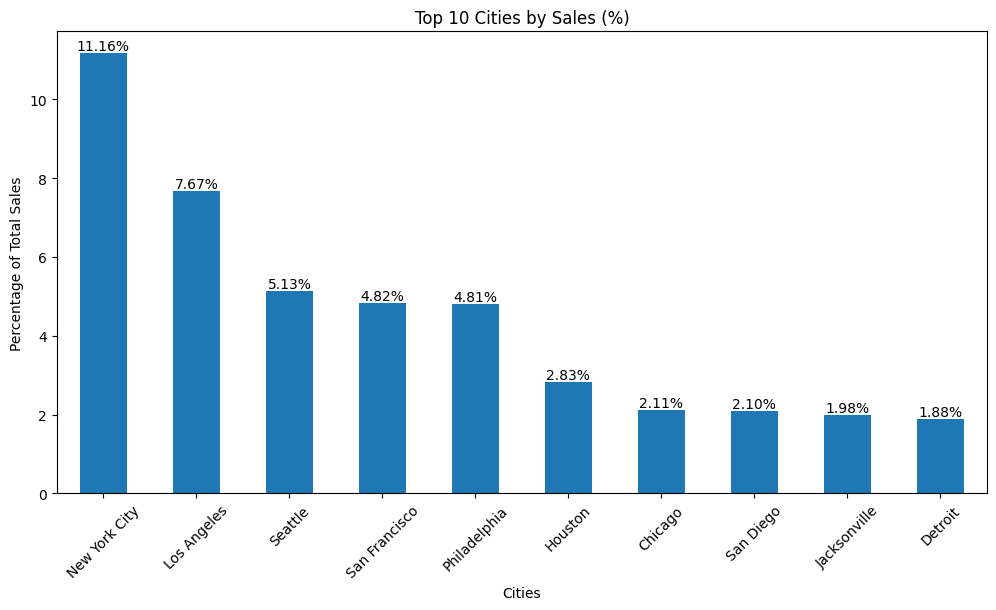

In [30]:
top_cities_pct = (top_cities / total_sales) * 100
plt.figure(figsize=(12,6))
ax = top_cities_pct.plot(kind = "bar")
plt.title("Top 10 Cities by Sales (%)")
plt.xlabel("Cities")
plt.ylabel("Percentage of Total Sales")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")


### Insight

Sales show a moderate level of geographic concentration.

At the state level, the top-performing state contributes approximately 20% of total sales, indicating the presence of a key market. However, the distribution across other states remains relatively balanced.

At the city level, the top city accounts for around 11% of total sales, suggesting a more diversified distribution across cities.

Overall, while certain locations play an important role, the business is not overly dependent on a single geographic market, reducing concentration risk.

## Product Analysis

Product analysis helps identify which categories and sub-categories contribute most to revenue and whether sales are concentrated in a narrow product mix.


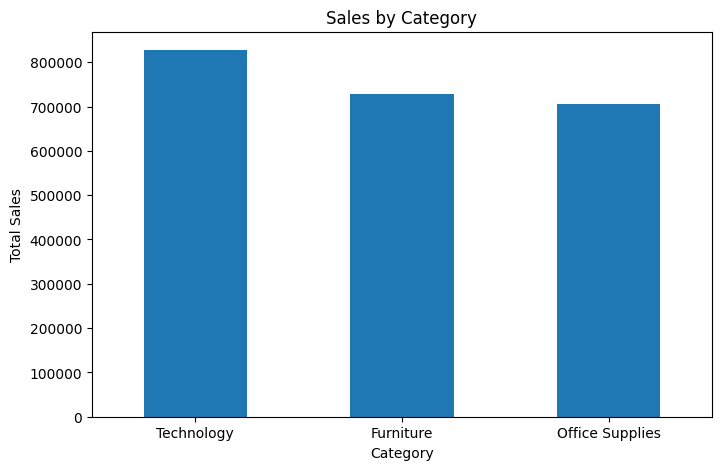

In [31]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()


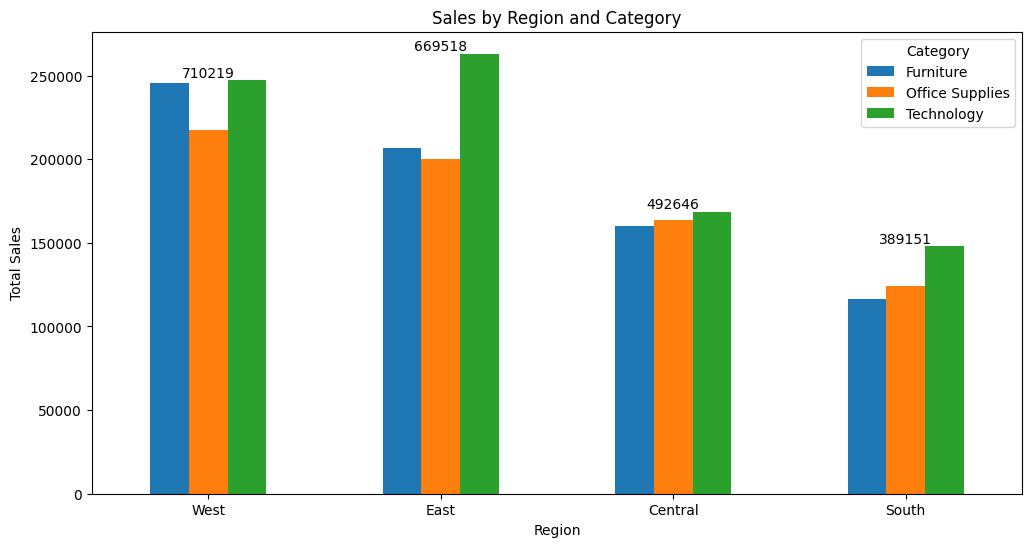

In [42]:
pivot = pd.pivot_table(
   df,
   values="Sales",
   index="Region",
   columns="Category",
   aggfunc="sum"
)

pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)

ax = pivot.drop(columns="Total").plot(kind="bar", figsize=(12, 6))
for i, total in enumerate(pivot["Total"]):
    y = pivot.drop(columns="Total").iloc[i].max()
    ax.text(
        i,
        y,
        f"{int(total)}",
        ha="center",
        va="bottom"
    )
plt.title("Sales by Region and Category")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()



### Insight

Technology is the leading product category across all regions, consistently contributing the largest share of sales.

However, the degree of dominance varies by region. In the East region, Technology significantly outperforms other categories, indicating a strong concentration in this segment.

In contrast, the West region shows a more balanced product mix, where Technology and Furniture contribute at similar levels.

This suggests that while Technology is a key revenue driver overall, regional differences in product mix indicate varying customer preferences and market dynamics.

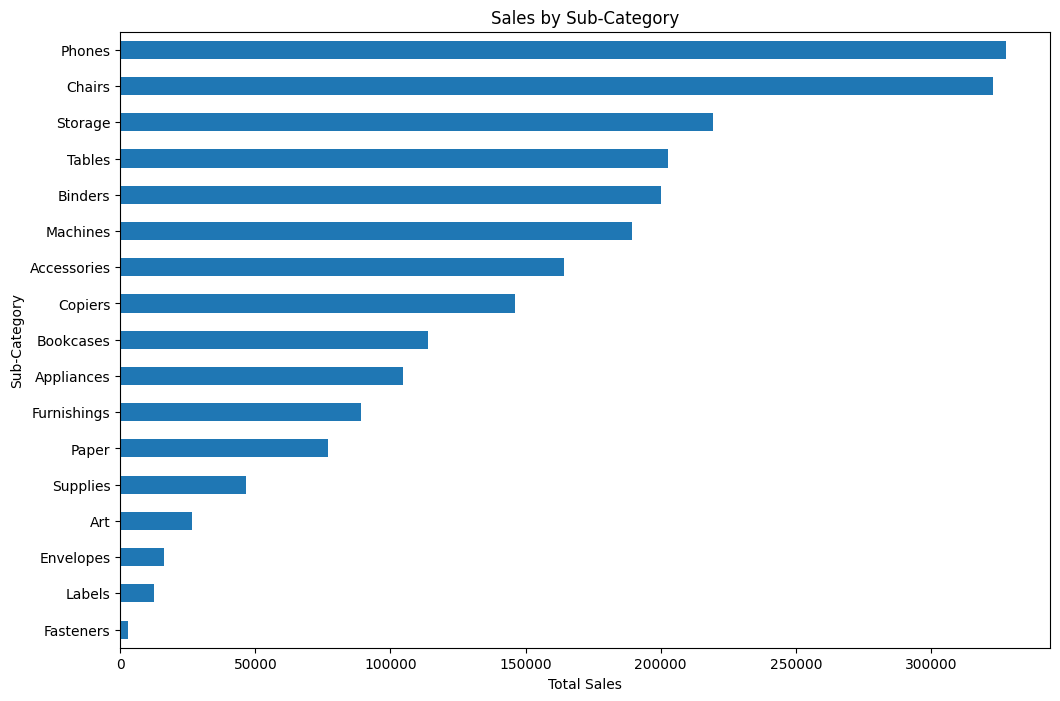

In [43]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values()

plt.figure(figsize=(12,8))
subcat_sales.plot(kind="barh")
plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()


### Insight

Sales are highly concentrated in a small number of sub-categories, with Phones and Chairs significantly outperforming all others.

A second tier of sub-categories, including Storage, Tables, and Binders, contributes moderately to overall sales but remains well below the top performers.

The remaining sub-categories form a long tail with relatively low sales contribution.

This distribution indicates a strong reliance on a few high-performing product lines, suggesting potential concentration risk as well as opportunities to optimize the product portfolio.

## Customer Segment Analysis

Different customer segments may contribute differently to overall sales. Understanding these differences can help improve targeting and customer strategy.


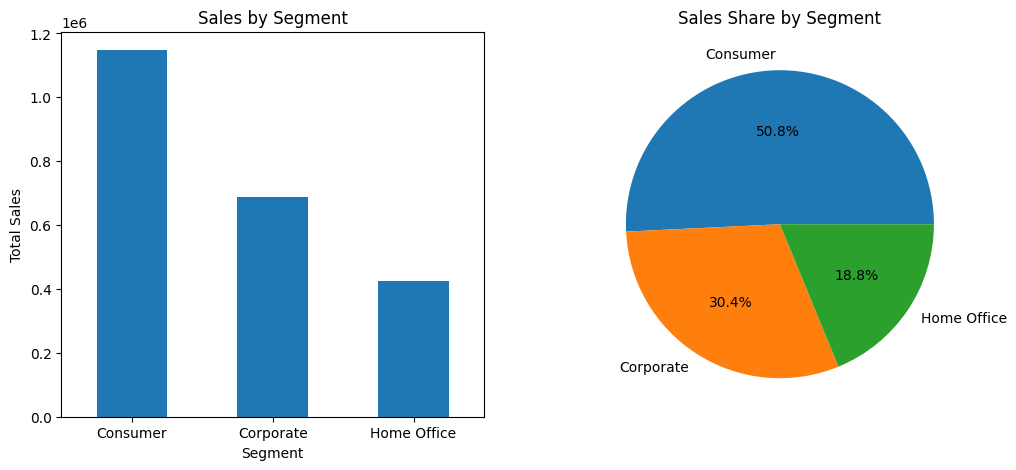

In [49]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

segment_sales.plot(kind="bar", ax=axes[0])
axes[0].set_title("Sales by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis='x', rotation=0)

segment_sales.plot(kind="pie",autopct="%.1f%%",ylabel="",ax=axes[1])
axes[1].set_title("Sales Share by Segment");

### Insight

The Consumer segment contributes the largest share of total sales, significantly outperforming Corporate and Home Office segments.

This indicates that individual consumers represent the primary customer base of the business.

Corporate customers also contribute a substantial portion, while the Home Office segment accounts for a smaller share, suggesting potential growth opportunities in this segment.

## Shipping Analysis

Shipping time is an important operational metric because delays may affect customer satisfaction and service quality.


In [56]:
print(f"The average processing time of an order is {round(df['processing_days'].mean(),2)} days")

The average processing time of an order is 3.96 days


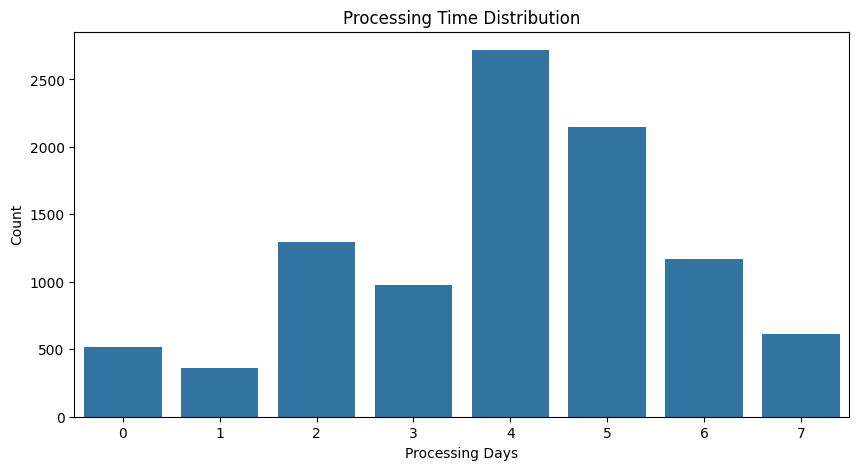

In [61]:
plt.figure(figsize=(10,5))
sns.countplot(x="processing_days", data=df)
plt.title("Processing Time Distribution")
plt.xlabel("Processing Days")
plt.ylabel("Count")
plt.show()



### Insight

Order processing time is distributed across discrete day values, with the highest frequency at around 4 days.

Most orders are processed within the 3–6 day range, indicating a consistent but moderately paced fulfillment process.

The distribution shows no extreme delays, suggesting stable operations, although faster processing (1–2 days) is relatively less common, indicating potential room for improvement.

## Conclusion

1. Sales exhibit both growth and seasonality  
Sales show a consistent upward trend over time, with clear seasonal patterns. Demand peaks in November–December and shows additional strength around September, indicating predictable demand cycles.

2. Regional performance is uneven but not highly concentrated  
While certain regions contribute more to total sales, the overall distribution remains relatively balanced. This suggests the presence of key markets without excessive dependence on a single region.

3. Sales are moderately concentrated geographically  
A small number of states and cities contribute a meaningful share of total revenue, but not to an extreme level. This indicates moderate concentration with manageable risk exposure.

4. Product performance is highly skewed toward Technology  
Technology is the leading category across all regions, and sub-category analysis shows strong reliance on top-performing products such as Phones and Chairs.

5. Product mix varies across regions  
Although Technology dominates overall, its relative contribution differs by region, with some regions showing more balanced product structures. This highlights differences in regional demand patterns.

6. Consumer segment is the primary revenue driver  
The Consumer segment contributes the largest share of sales, indicating that individual customers form the core customer base.

7. Order processing is stable but not highly efficient  
Most orders are processed within 3–6 days, with a peak around 4 days. While extreme delays are rare, faster processing times are relatively uncommon, suggesting opportunities to improve operational efficiency.

Overall, the business demonstrates stable growth with identifiable demand patterns, but shows opportunities in product diversification, regional optimization, and operational efficiency improvements.